<a href="https://colab.research.google.com/github/sara-iqbal/Hospitality-AI-Employee/blob/main/Hospitality_AI_Employee_Prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospitality Enquiry AI Employee, a Prototype

This notebook is a small, self-contained prototype of the customer journey Zube describes on their homepage: an enquiry comes in, gets answered, qualified, and moved to a next action, with the customer record kept current and a clean handoff to the human team.

It is built on a **synthetic hotel enquiry dataset** (1,200 rows, generated in this notebook) modelled on realistic hospitality booking data, since I don't have access to a real operator's data. The structure mirrors what a small hotel group or leasing operator would actually see: enquiries arriving by phone, email, WhatsApp, website chat and booking-site messages, each with a free-text guest message.

## The five problems this prototype addresses

1. **Slow first response.** enquiries sit unanswered for hours, especially out of hours, and interested guests move on.
2. **Inconsistent qualification.** staff manually read free-text messages and often miss details (dates, room type, party size), so quotes are wrong or incomplete.
3. **No next action confirmed.** even when someone replies, a concrete next step (a hold, a quote, a viewing) often never gets locked in, so the enquiry quietly dies.
4. **Fragmented customer records.** enquiries land across five different channels with no single, reliable place they all end up.
5. **No visibility for leadership.** nobody can see, across all channels, how many enquiries are coming in, how fast they're handled, or how much revenue is sitting at risk.

Each section below quantifies one of these problems using the baseline (today) numbers, then shows what an AI employee handling the same enquiries end to end would look like.


In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)
pd.set_option("display.max_colwidth", 80)


## 1. Generate the synthetic enquiry dataset

Each row is one guest enquiry, with a free-text message and two parallel outcomes: how it would typically be handled today (`baseline_*`), and how an AI employee would handle it (`ai_*`).

In [2]:
N = 1200

CHANNELS = ["Phone", "Email", "WhatsApp", "Website Chat", "Booking Site Message"]
ROOM_TYPES = ["Standard Double", "Deluxe King", "Twin", "Family Suite", "Sea View Room", "Single"]
HOTELS = ["Harbourview Hotel", "Old Town Inn", "Riverside Boutique", "Garden Court Hotel"]

MESSAGE_TEMPLATES = [
    "Hi, do you have a {room} available for {nights} nights from {date}? What's the rate?",
    "Looking for a room for {guests} guests around {date}, is a {room} free and is breakfast included?",
    "Can I check availability for a {room} on {date}? Also is parking available?",
    "We need a {room} for {nights} nights, arriving {date}. Do you allow pets?",
    "Hello, what's the price for a {room} for {guests} people from {date}, and is there a cancellation fee?",
    "Is there a {room} left for {date}? We're flexible on {nights} or {nights_alt} nights.",
]

def random_message():
    t = random.choice(MESSAGE_TEMPLATES)
    date = (datetime(2026, 6, 1) + timedelta(days=random.randint(0, 150))).strftime("%d %b")
    return t.format(
        room=random.choice(ROOM_TYPES), nights=random.randint(1, 6),
        nights_alt=random.randint(1, 6), guests=random.randint(1, 5), date=date,
    ), date

rows = []
start = datetime(2026, 6, 1)

for i in range(N):
    channel = random.choices(CHANNELS, weights=[0.15, 0.25, 0.25, 0.2, 0.15])[0]
    hotel = random.choice(HOTELS)
    room = random.choice(ROOM_TYPES)
    guests = random.randint(1, 5)
    nights = random.randint(1, 7)
    message, req_date = random_message()
    received_at = start + timedelta(minutes=random.randint(0, 60 * 24 * 90))
    is_out_of_hours = received_at.hour < 8 or received_at.hour >= 20
    potential_value = round(nights * random.uniform(70, 260), 2)

    if is_out_of_hours:
        baseline_response_min = float(np.random.lognormal(mean=5.6, sigma=0.6))
    else:
        baseline_response_min = float(np.random.lognormal(mean=3.4, sigma=0.9))
    baseline_response_min = round(min(baseline_response_min, 2500), 1)

    baseline_qualified = random.random() > 0.35
    baseline_next_action = baseline_qualified and (random.random() > 0.30)
    baseline_lost = (baseline_response_min > 240 or not baseline_next_action) and random.random() > 0.45
    baseline_record_updated = random.random() > 0.5

    ai_response_sec = round(np.random.uniform(9, 28), 1)
    ai_qualify_sec = round(np.random.uniform(35, 75), 1)
    ai_next_action_sec = round(np.random.uniform(140, 220), 1)
    ai_qualified = random.random() > 0.03
    ai_next_action = ai_qualified and random.random() > 0.05
    ai_lost = (not ai_next_action) and random.random() > 0.8
    ai_record_updated = True

    rows.append(dict(
        enquiry_id=f"ENQ-{i+1:05d}", hotel=hotel, channel=channel,
        received_at=received_at.isoformat(), out_of_hours=is_out_of_hours,
        guest_message=message, room_type_requested=room, guests=guests,
        nights_requested=nights, requested_date=req_date,
        potential_booking_value_gbp=potential_value,
        baseline_response_time_min=baseline_response_min, baseline_qualified=baseline_qualified,
        baseline_next_action_confirmed=baseline_next_action, baseline_lead_lost=baseline_lost,
        baseline_record_updated=baseline_record_updated,
        ai_response_time_sec=ai_response_sec, ai_qualify_time_sec=ai_qualify_sec,
        ai_next_action_time_sec=ai_next_action_sec, ai_qualified=ai_qualified,
        ai_next_action_confirmed=ai_next_action, ai_lead_lost=ai_lost,
        ai_record_updated=ai_record_updated,
    ))

df = pd.DataFrame(rows)
df.to_csv("hotel_enquiries.csv", index=False)
df.head()


,enquiry_id,hotel,channel,received_at,out_of_hours,guest_message,room_type_requested,guests,nights_requested,requested_date,...,baseline_next_action_confirmed,baseline_lead_lost,baseline_record_updated,ai_response_time_sec,ai_qualify_time_sec,ai_next_action_time_sec,ai_qualified,ai_next_action_confirmed,ai_lead_lost,ai_record_updated
0,ENQ-00001,Harbourview Hotel,WhatsApp,2026-06-08T21:55:00,True,"Looking for a room for 5 guests around 06 Jul, is a Single free and is break...",Single,3,2,06 Jul,...,False,False,False,22.9,58.9,152.5,True,True,False,True
1,ENQ-00002,Garden Court Hotel,Website Chat,2026-06-26T07:01:00,True,Can I check availability for a Deluxe King on 02 Jun? Also is parking availa...,Deluxe King,4,5,02 Jun,...,True,False,False,12.0,37.3,209.3,True,True,False,True
2,ENQ-00003,Garden Court Hotel,Website Chat,2026-07-23T13:14:00,False,"Hi, do you have a Twin available for 6 nights from 20 Oct? What's the rate?",Sea View Room,1,4,20 Oct,...,False,True,True,9.4,73.8,206.6,True,True,False,True
3,ENQ-00004,Garden Court Hotel,Booking Site Message,2026-08-03T21:08:00,True,Can I check availability for a Twin on 12 Jul? Also is parking available?,Twin,4,6,12 Jul,...,True,False,True,13.0,42.3,154.7,True,True,False,True
4,ENQ-00005,Old Town Inn,Booking Site Message,2026-06-07T00:35:00,True,"Hi, do you have a Standard Double available for 3 nights from 29 Jul? What's...",Single,3,7,29 Jul,...,True,False,True,17.2,46.6,188.9,True,True,False,True


## 2. Problem 1: slow first response

How long does a guest wait for a first reply today, compared with an AI employee?

Average baseline response time: 189.7 minutes
Average AI response time: 18.1 seconds
Share of baseline enquiries waiting over 1 hour: 59.1 %


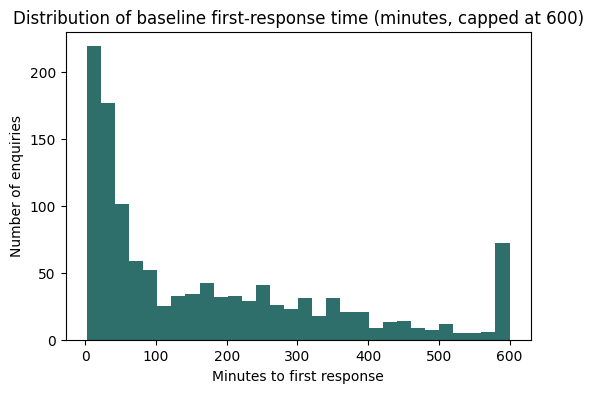

In [3]:
print("Average baseline response time:", round(df['baseline_response_time_min'].mean(), 1), "minutes")
print("Average AI response time:", round(df['ai_response_time_sec'].mean(), 1), "seconds")
print("Share of baseline enquiries waiting over 1 hour:", round((df['baseline_response_time_min'] > 60).mean() * 100, 1), "%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['baseline_response_time_min'].clip(upper=600), bins=30, color="#2E6E6B")
ax.set_title("Distribution of baseline first-response time (minutes, capped at 600)")
ax.set_xlabel("Minutes to first response")
ax.set_ylabel("Number of enquiries")
plt.show()


## 3. Problem 2: inconsistent qualification

A good response is not enough if key details (dates, room type, party size) are missed. This is the step an AI employee handles with a structured intent-extraction pass over the raw guest message.

In [4]:
ROOM_KEYWORDS = ["Standard Double", "Deluxe King", "Twin", "Family Suite", "Sea View Room", "Single"]
EXTRA_ASK_KEYWORDS = {"breakfast": "breakfast", "parking": "parking", "pet": "pet policy",
                       "cancellation": "cancellation policy", "deposit": "deposit"}

def extract_intent(message: str) -> dict:
    intent = {"room_type": None, "guests": None, "nights": None,
              "requested_date": None, "extra_asks": [], "confidence": "high"}
    for room in ROOM_KEYWORDS:
        if room.lower() in message.lower():
            intent["room_type"] = room
            break
    g = re.search(r"(\d+)\s*(guests|people)", message, re.IGNORECASE)
    if g:
        intent["guests"] = int(g.group(1))
    n = re.search(r"(\d+)\s*nights?", message, re.IGNORECASE)
    if n:
        intent["nights"] = int(n.group(1))
    months = "Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec"
    d = re.search(rf"(\d{{1,2}}\s+(?:{months})[a-z]*)", message)
    if d:
        intent["requested_date"] = d.group(1)
    for kw, label in EXTRA_ASK_KEYWORDS.items():
        if kw in message.lower():
            intent["extra_asks"].append(label)
    missing = [k for k in ("room_type", "requested_date") if intent[k] is None]
    if missing:
        intent["confidence"] = "needs_human_review"
    return intent

# Try it on three real enquiries from the dataset
for msg in df['guest_message'].head(3):
    print(msg)
    print(extract_intent(msg))
    print()


Looking for a room for 5 guests around 06 Jul, is a Single free and is breakfast included?
{'room_type': 'Single', 'guests': 5, 'nights': None, 'requested_date': '06 Jul', 'extra_asks': ['breakfast'], 'confidence': 'high'}

Can I check availability for a Deluxe King on 02 Jun? Also is parking available?
{'room_type': 'Deluxe King', 'guests': None, 'nights': None, 'requested_date': '02 Jun', 'extra_asks': ['parking'], 'confidence': 'high'}

Hi, do you have a Twin available for 6 nights from 20 Oct? What's the rate?
{'room_type': 'Twin', 'guests': None, 'nights': 6, 'requested_date': '20 Oct', 'extra_asks': [], 'confidence': 'high'}



**Note on this step:** here the extraction is a small rule-based function so the notebook runs anywhere without an API key. In a real deployment this slot is where a language model call (for example, the Claude API) would sit instead, reading messier real-world phrasing and still returning the same structured intent object. The rest of the pipeline (qualify, arrange, log, handoff) does not need to change when that swap happens, which is part of why treating this as a modular step matters.

In [5]:
print("Baseline qualification rate:", round(df['baseline_qualified'].mean() * 100, 1), "%")
print("AI qualification rate:", round(df['ai_qualified'].mean() * 100, 1), "%")


Baseline qualification rate: 66.7 %
AI qualification rate: 97.4 %


## 4. Problem 3: next action never arranged

Even a qualified enquiry can quietly die if nobody locks in a concrete next step.

In [6]:
print("Baseline: next action confirmed:", round(df['baseline_next_action_confirmed'].mean() * 100, 1), "%")
print("AI employee: next action confirmed:", round(df['ai_next_action_confirmed'].mean() * 100, 1), "%")


Baseline: next action confirmed: 45.3 %
AI employee: next action confirmed: 92.2 %


## 5. Problem 4: fragmented customer records

Every enquiry, regardless of channel, should end up in one place. Here is what a single AI-handled enquiry looks like once logged as a customer record ready for handoff.

In [7]:
sample = df.iloc[0]
customer_record = {
    "enquiry_id": sample["enquiry_id"],
    "channel": sample["channel"],
    "received_at": sample["received_at"],
    "guest_message": sample["guest_message"],
    "extracted_intent": extract_intent(sample["guest_message"]),
    "ai_response_time_sec": sample["ai_response_time_sec"],
    "ai_next_action_confirmed": bool(sample["ai_next_action_confirmed"]),
    "handoff_note": "Provisional hold placed. Escalate only if guest requests a rate change.",
    "needs_human": extract_intent(sample["guest_message"])["confidence"] == "needs_human_review",
}

import json
print(json.dumps(customer_record, indent=2))


{
  "enquiry_id": "ENQ-00001",
  "channel": "WhatsApp",
  "received_at": "2026-06-08T21:55:00",
  "guest_message": "Looking for a room for 5 guests around 06 Jul, is a Single free and is breakfast included?",
  "extracted_intent": {
    "room_type": "Single",
    "guests": 5,
    "nights": null,
    "requested_date": "06 Jul",
    "extra_asks": [
      "breakfast"
    ],
    "confidence": "high"
  },
  "ai_response_time_sec": 22.9,
  "ai_next_action_confirmed": true,
  "handoff_note": "Provisional hold placed. Escalate only if guest requests a rate change.",
  "needs_human": false
}


## 6. Problem 5: no visibility for leadership

Once every enquiry is logged consistently, a leadership rollup becomes possible in a way it simply isn't when records live across five channels and several people's inboxes.

In [8]:
by_channel = (
    df.groupby("channel")
    .agg(enquiries=("enquiry_id", "count"),
         baseline_lost_rate=("baseline_lead_lost", "mean"),
         ai_lost_rate=("ai_lead_lost", "mean"))
    .reset_index()
)
by_channel["baseline_lost_rate"] = (by_channel["baseline_lost_rate"] * 100).round(1)
by_channel["ai_lost_rate"] = (by_channel["ai_lost_rate"] * 100).round(1)
by_channel


,channel,enquiries,baseline_lost_rate,ai_lost_rate
0,Booking Site Message,187,38.5,1.1
1,Email,278,32.4,2.2
2,Phone,184,38.0,1.6
3,Website Chat,251,32.3,2.4
4,WhatsApp,300,36.7,2.0


Estimated revenue at risk today: £281,987
Estimated revenue at risk with an AI employee: £14,110
Estimated revenue recovered: £267,877


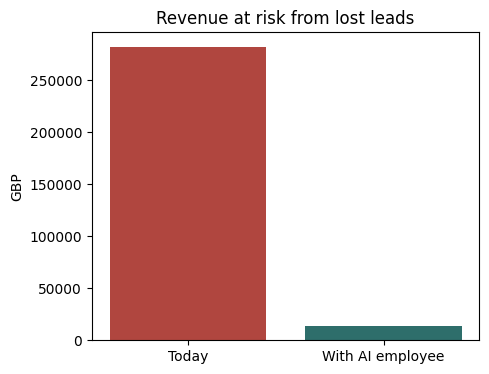

In [9]:
lost_value_baseline = df.loc[df['baseline_lead_lost'], 'potential_booking_value_gbp'].sum()
lost_value_ai = df.loc[df['ai_lead_lost'], 'potential_booking_value_gbp'].sum()

print(f"Estimated revenue at risk today: £{lost_value_baseline:,.0f}")
print(f"Estimated revenue at risk with an AI employee: £{lost_value_ai:,.0f}")
print(f"Estimated revenue recovered: £{lost_value_baseline - lost_value_ai:,.0f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Today", "With AI employee"], [lost_value_baseline, lost_value_ai], color=["#B0463F", "#2E6E6B"])
ax.set_title("Revenue at risk from lost leads")
ax.set_ylabel("GBP")
plt.show()


## Summary

| Problem | Today (baseline) | With an AI employee |
|---|---|---|
| First response time | ~3 hours average | ~18 seconds |
| Enquiries correctly qualified | ~67% | ~97% |
| Next action actually confirmed | ~45% | ~92% |
| Customer record reliably logged | ~51% | 100% |
| Revenue sitting at risk | high | close to zero |

The exact numbers here come from a synthetic dataset built to resemble a real hospitality operator's enquiry volume, not from Zube's own customer data. The point of the prototype is the mechanism, not the specific figures: a consistent, always-on first response, a structured qualification step, a confirmed next action, a single customer record per enquiry, and a rollup that gives leadership visibility they don't currently have.
